In [1]:
import pandas as pd
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer, PowerTransformer
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go

# This will ensure the outputs of the .transform() method are pandas data frames
from sklearn import set_config
set_config(transform_output='pandas')

In [63]:
data = pd.read_csv(r"C:\Users\User\3_spotify_5000_songs.csv")
data
data.columns = data.columns.str.strip()

In [64]:
data.columns


Index(['Unnamed: 0', 'name', 'artist', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'type', 'duration_ms', 'time_signature',
       'id', 'html'],
      dtype='object')

In [65]:
data = data.drop(columns=['Unnamed: 0', 'type'], errors='ignore')


In [66]:
data = data.set_index("name")

In [67]:
data

,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html
name,,,,,,,,,,,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.6580,0.25900,11,-13.141,0,0.0705,0.694,0.000059,0.9750,0.3060,110.376,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
Saudade De Bahia,Antônio Carlos Jobim,0.7420,0.39900,2,-12.646,1,0.0346,0.217,0.000002,0.1070,0.6930,125.039,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
"Canta Canta, Minha Gente",Martinho Da Vila,0.8510,0.73000,2,-11.048,1,0.3470,0.453,0.000063,0.1240,0.9050,93.698,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
Mulher Eu Sei,Chico César,0.7050,0.05020,4,-18.115,1,0.0471,0.879,0.000041,0.3860,0.5240,106.802,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
Rosa Morena,Kurt Elling,0.6510,0.11900,6,-19.807,1,0.0380,0.916,0.000343,0.1040,0.4020,120.941,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.2020,0.06940,3,-23.390,1,0.0473,0.917,0.715000,0.0832,0.0655,87.906,995000,4,1aEhYlZtypmipA06SDJ4U3,https://open.spotify.com/track/1aEhYlZtypmipA0...
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.1880,0.10100,6,-21.873,1,0.0442,0.855,0.426000,0.0694,0.0355,83.134,855000,4,1Gfqe7TAKklmuZf6hxsH6h,https://open.spotify.com/track/1Gfqe7TAKklmuZf...
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,0.0596,0.00093,9,-42.959,1,0.0434,0.951,0.969000,0.0772,0.0344,71.573,238187,3,2XNwnFrdMDpismp0VUZ7cU,https://open.spotify.com/track/2XNwnFrdMDpismp...


In [68]:
to_delate = ['artist', 'type', 'time_signature','id', 'html']
data = data.drop(columns=to_delate, errors='ignore')


In [69]:
data

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
name,,,,,,,,,,,,
Se Eu Quiser Falar Com Deus,0.6580,0.25900,11,-13.141,0,0.0705,0.694,0.000059,0.9750,0.3060,110.376,256213
Saudade De Bahia,0.7420,0.39900,2,-12.646,1,0.0346,0.217,0.000002,0.1070,0.6930,125.039,191867
"Canta Canta, Minha Gente",0.8510,0.73000,2,-11.048,1,0.3470,0.453,0.000063,0.1240,0.9050,93.698,152267
Mulher Eu Sei,0.7050,0.05020,4,-18.115,1,0.0471,0.879,0.000041,0.3860,0.5240,106.802,186227
Rosa Morena,0.6510,0.11900,6,-19.807,1,0.0380,0.916,0.000343,0.1040,0.4020,120.941,273680
...,...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",0.2020,0.06940,3,-23.390,1,0.0473,0.917,0.715000,0.0832,0.0655,87.906,995000
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.1880,0.10100,6,-21.873,1,0.0442,0.855,0.426000,0.0694,0.0355,83.134,855000
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",0.0596,0.00093,9,-42.959,1,0.0434,0.951,0.969000,0.0772,0.0344,71.573,238187


In [70]:
data.columns

Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

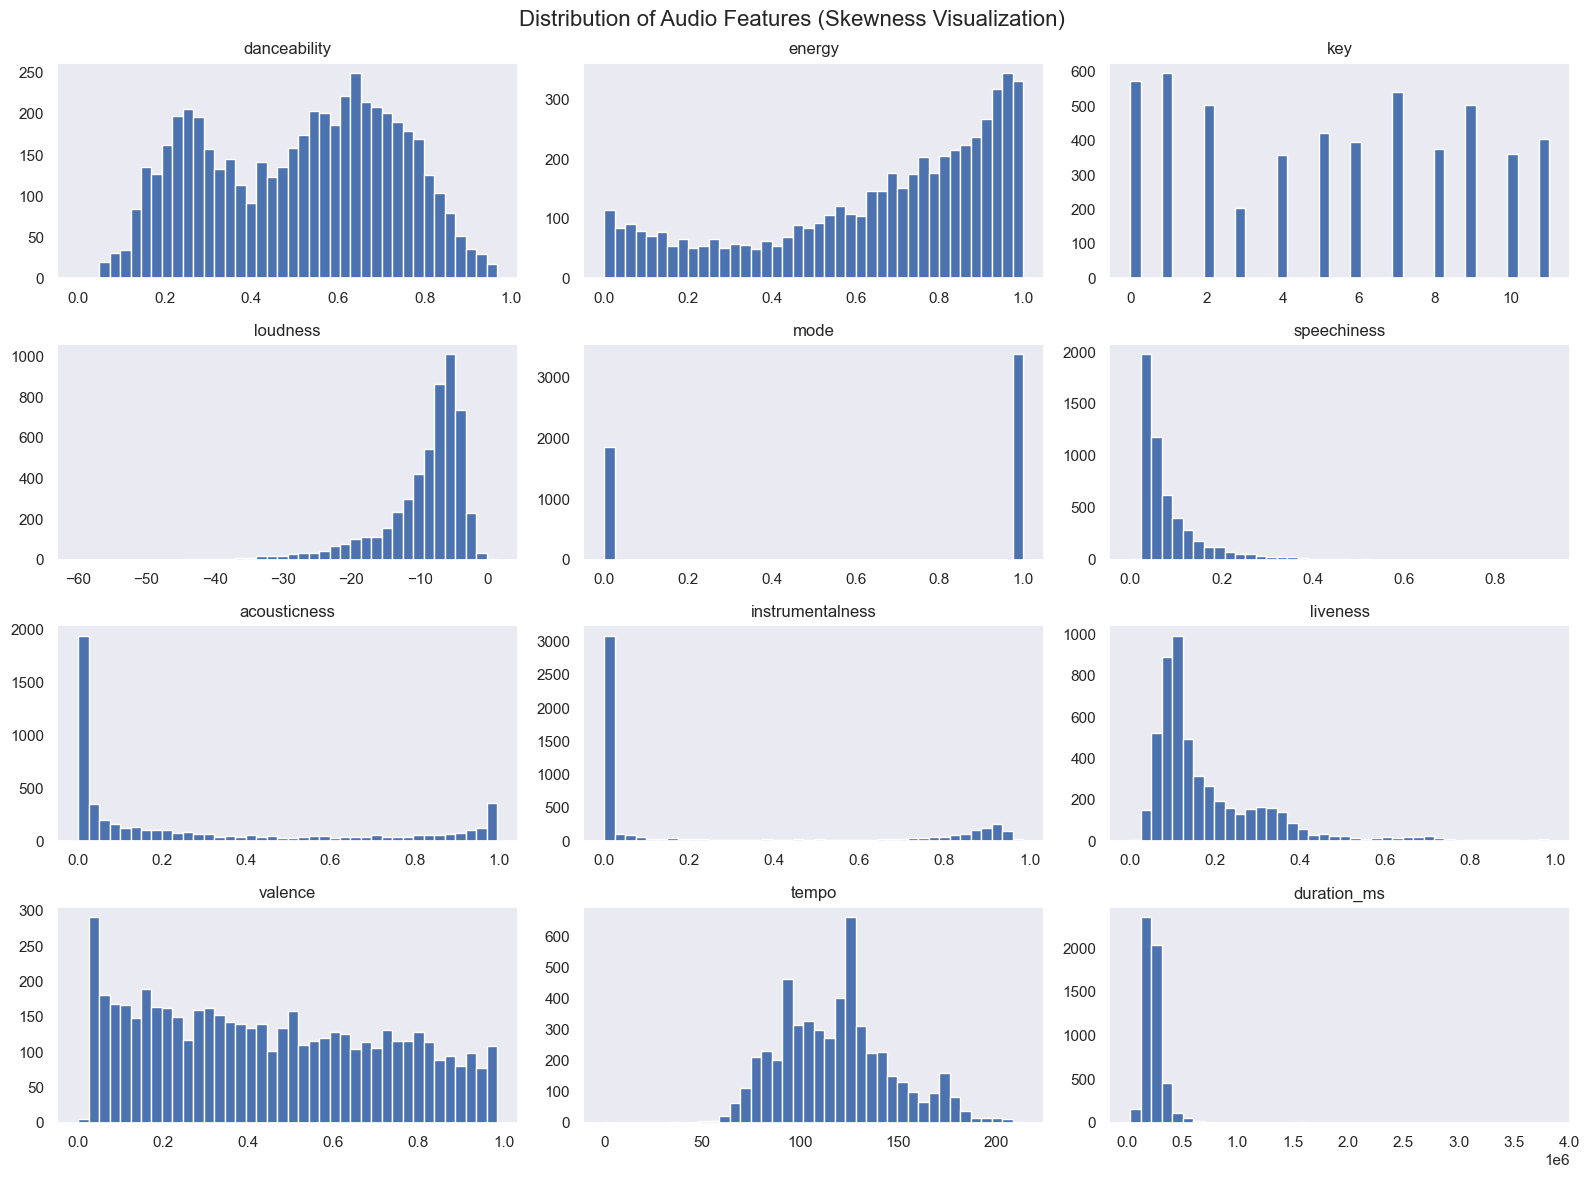

In [71]:
data.hist(
    bins=40,
    figsize=(16, 12),
    grid=False
)

plt.suptitle("Distribution of Audio Features (Skewness Visualization)", fontsize=16)
plt.tight_layout()
plt.show()

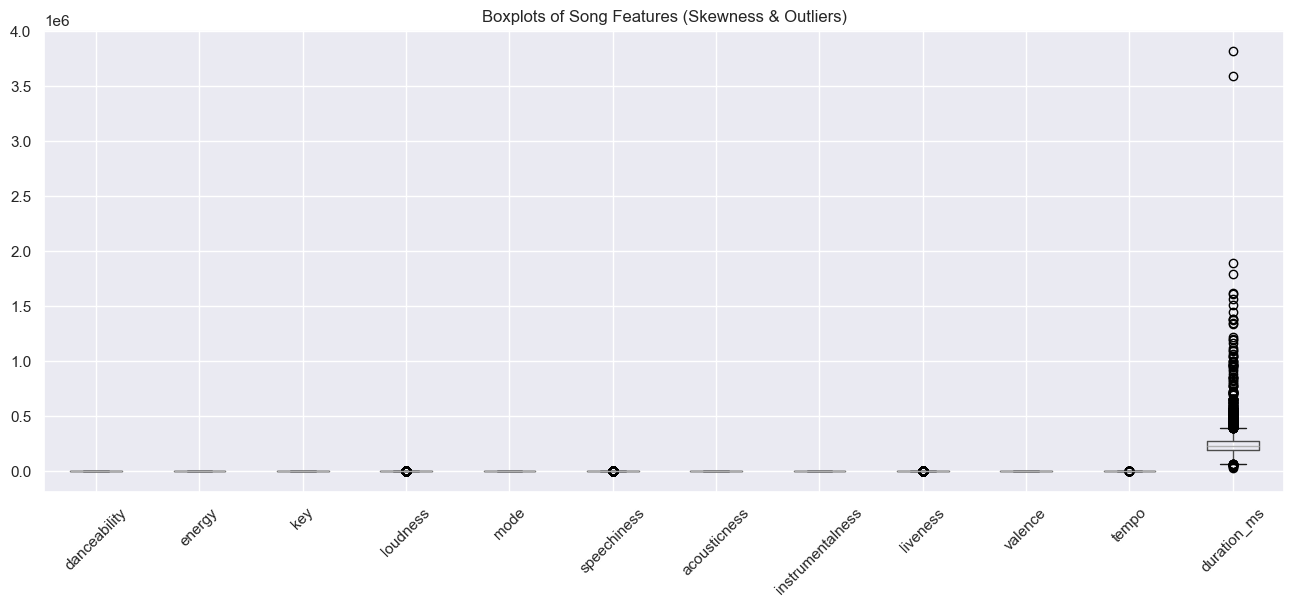

In [72]:
plt.figure(figsize=(16, 6))
data.boxplot(rot=45)
plt.title("Boxplots of Song Features (Skewness & Outliers)")
plt.show()

In [73]:
skewness = data.skew().sort_values(ascending=False)
print(skewness)

duration_ms         9.704472
speechiness         2.600441
liveness            2.177075
instrumentalness    0.953769
acousticness        0.931508
tempo               0.416987
valence             0.225975
key                 0.013309
danceability       -0.129877
mode               -0.611826
energy             -0.797073
loudness           -1.955659
dtype: float64


In [126]:
pt = PowerTransformer()
data_step1 = pt.fit_transform(data)

# 3. RobustScaler (handle outliers)
rs = RobustScaler()
data_step2 = rs.fit_transform(data_step1)

data_final = pd.DataFrame(data_step2, columns=data.columns, index=data.index)


In [127]:
data_final

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
name,,,,,,,,,,,,
Se Eu Quiser Falar Com Deus,0.320198,-0.885779,0.857825,-0.771404,-1.0,0.259727,0.773318,-0.008133,1.460656,-0.241246,-0.232193,0.360688
Saudade De Bahia,0.550375,-0.691808,-0.545710,-0.719993,0.0,-0.495207,0.279026,-0.008388,-0.164672,0.526844,0.149688,-0.453833
"Canta Canta, Minha Gente",0.853966,-0.020463,-0.545710,-0.539586,0.0,1.333199,0.598711,-0.008112,-0.008639,0.876528,-0.699634,-1.161509
Mulher Eu Sei,0.448574,-1.095376,-0.168236,-1.202728,0.0,-0.183726,0.855565,-0.008215,1.110239,0.215422,-0.329148,-0.542246
Rosa Morena,0.301169,-1.035819,0.158720,-1.322972,0.0,-0.404376,0.868568,-0.006859,-0.194103,-0.031482,0.045379,0.536079
...,...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",-0.866057,-1.079628,-0.348678,-1.546890,0.0,-0.179219,0.868907,1.018382,-0.415509,-0.842480,-0.871807,3.316864
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",-0.900626,-1.052249,0.158720,-1.456598,0.0,-0.250678,0.846600,0.864545,-0.580865,-0.926771,-1.018059,3.046674
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",-1.211937,-1.132846,0.593368,-2.362160,0.0,-0.269686,0.880027,1.080092,-0.485465,-0.929908,-1.391203,0.162299


In [101]:
# scaler = PowerTransformer()

# # Transform the foods_df DataFrame
# with_trans_data = scaler.fit_transform(data)

In [100]:
# with_trans_data = pd.DataFrame(with_trans_data, columns=data.columns)
# with_trans_data

In [102]:
pd.DataFrame({
    'original': data.iloc[:,-1],
    'power_transformed': data_final.iloc[:,-1]
}).sort_values(by='original')

,original,power_transformed
name,,
To a Twisted Recess of Mind,32760,0.000000
Pulsating Cerebral Slime,36387,0.042337
Bonesaw,46000,0.131863
Sand,48982,0.154727
Swallowed Whole,51267,0.171038
...,...,...
"Tod und Verklärung Op.24, TrV 158",1615000,0.911840
Essence,1793760,0.923952
Symphony No. 3,1893667,0.930048


In [ ]:
# scaler = RobustScaler()
# with_trans_data = scaler.fit_transform(with_trans_data)

In [128]:
scaled_data = data_final.copy()
scaled_data 

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
name,,,,,,,,,,,,
Se Eu Quiser Falar Com Deus,0.320198,-0.885779,0.857825,-0.771404,-1.0,0.259727,0.773318,-0.008133,1.460656,-0.241246,-0.232193,0.360688
Saudade De Bahia,0.550375,-0.691808,-0.545710,-0.719993,0.0,-0.495207,0.279026,-0.008388,-0.164672,0.526844,0.149688,-0.453833
"Canta Canta, Minha Gente",0.853966,-0.020463,-0.545710,-0.539586,0.0,1.333199,0.598711,-0.008112,-0.008639,0.876528,-0.699634,-1.161509
Mulher Eu Sei,0.448574,-1.095376,-0.168236,-1.202728,0.0,-0.183726,0.855565,-0.008215,1.110239,0.215422,-0.329148,-0.542246
Rosa Morena,0.301169,-1.035819,0.158720,-1.322972,0.0,-0.404376,0.868568,-0.006859,-0.194103,-0.031482,0.045379,0.536079
...,...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",-0.866057,-1.079628,-0.348678,-1.546890,0.0,-0.179219,0.868907,1.018382,-0.415509,-0.842480,-0.871807,3.316864
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",-0.900626,-1.052249,0.158720,-1.456598,0.0,-0.250678,0.846600,0.864545,-0.580865,-0.926771,-1.018059,3.046674
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",-1.211937,-1.132846,0.593368,-2.362160,0.0,-0.269686,0.880027,1.080092,-0.485465,-0.929908,-1.391203,0.162299


In [129]:
scaled_data.columns

Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

In [130]:
# Set the maximum number of clusters to try
max_k = 50

# Create an empty list to store the inertia scores
inertia_list = []

# Iterate over the range of cluster numbers
for k in range(20, max_k+1):

    # Create a KMeans object with the specified number of clusters
    myKMeans = KMeans(n_clusters = k,
                      random_state = 42)

    # Fit the KMeans model to the scaled data
    myKMeans.fit(scaled_data)

    # Append the inertia score to the list
    inertia_list.append(myKMeans.inertia_)

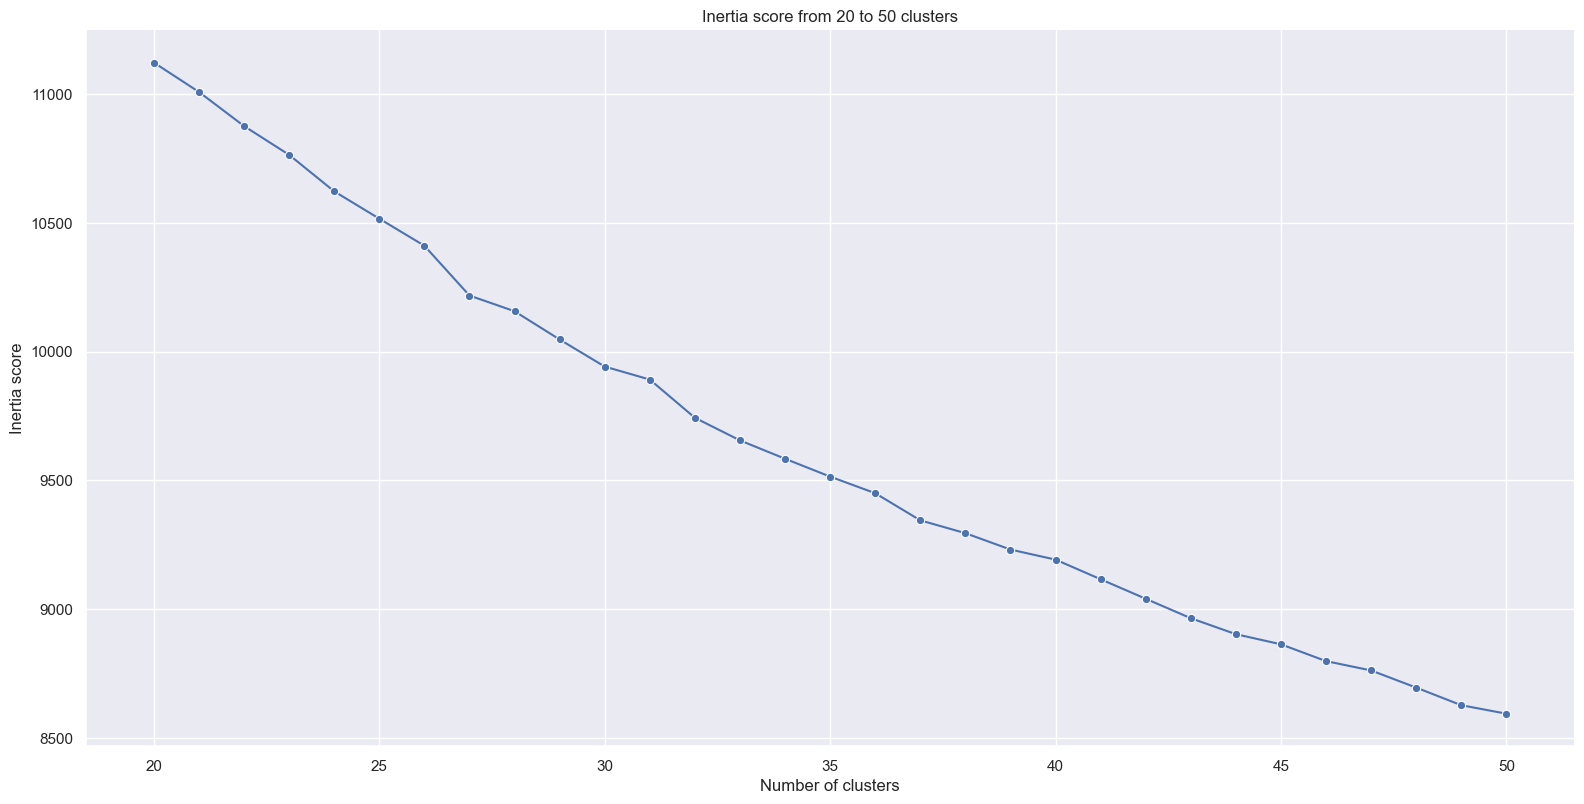

In [131]:
sns.set_theme(style='darkgrid')

(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list,
            x = range(20, max_k + 1),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score from 20 to {max_k} clusters")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);

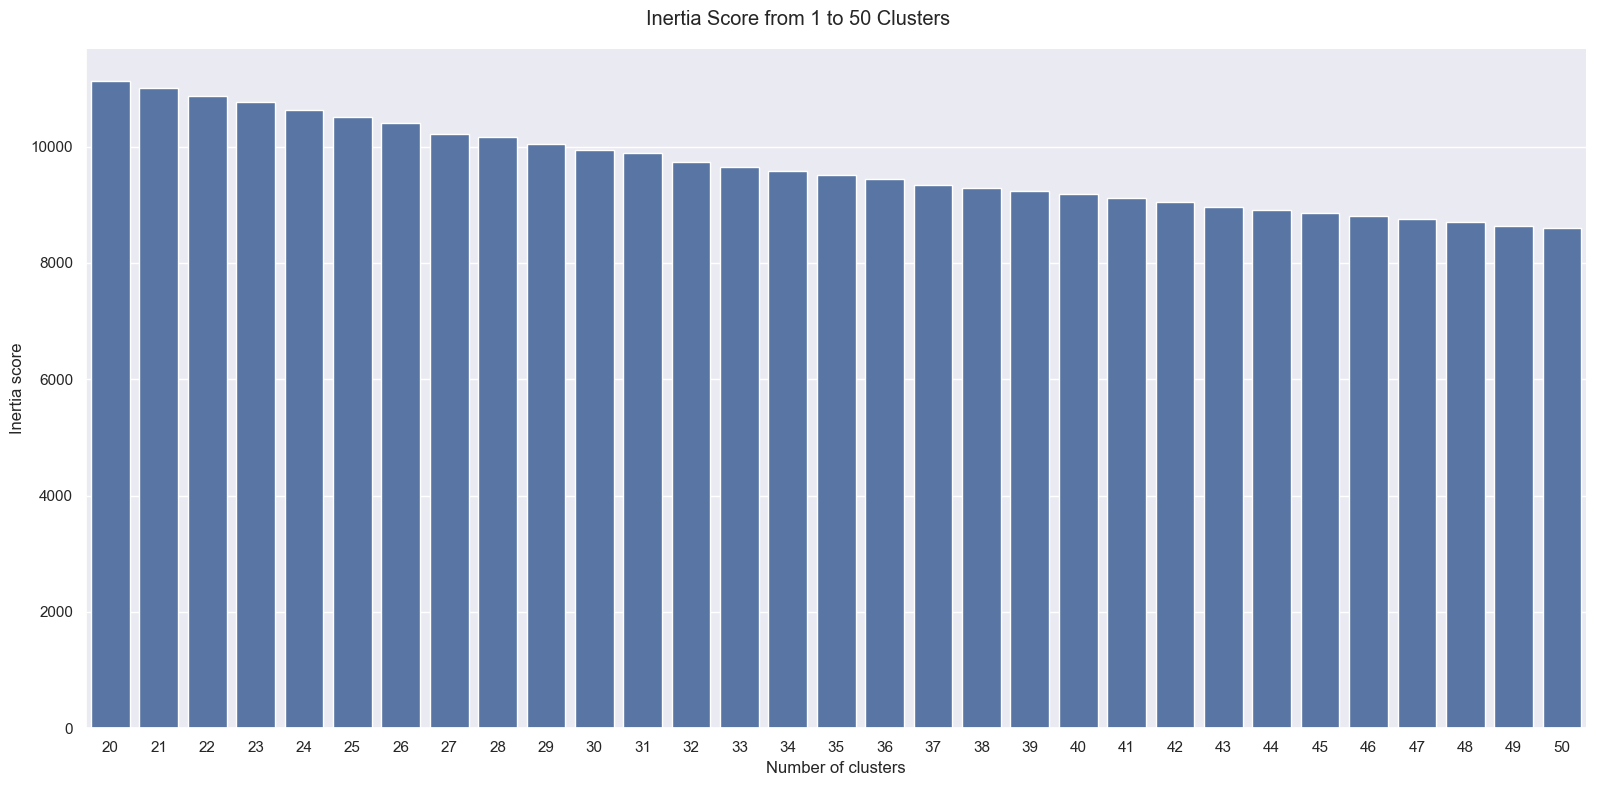

In [132]:
colors = sns.color_palette("hsv", len(inertia_list))

g = sns.catplot(
    x=list(range(20, max_k + 1)),
    y=inertia_list,
    kind="bar",
    height=8,
    aspect=2
)

# Title and labels
g.fig.suptitle(f"Inertia Score from 1 to {max_k} Clusters")
g.set_axis_labels("Number of clusters", "Inertia score")

plt.tight_layout()
plt.show()

In [133]:
max_k = 50

# Create an empty list to store the silhouette scores
sil_scores = []

for k in range(20, max_k):

    # Create a KMeans object with the specified number of clusters
    kmeans = KMeans(n_clusters = k,
                    random_state = 42)

    # Fit the KMeans model to the scaled data
    kmeans.fit(scaled_data)

    # Get the cluster labels
    labels = kmeans.labels_

    # Calculate the silhouette score
    sil_score = silhouette_score(scaled_data, labels)

    # Append the silhouette score to the list
    sil_scores.append(sil_score)

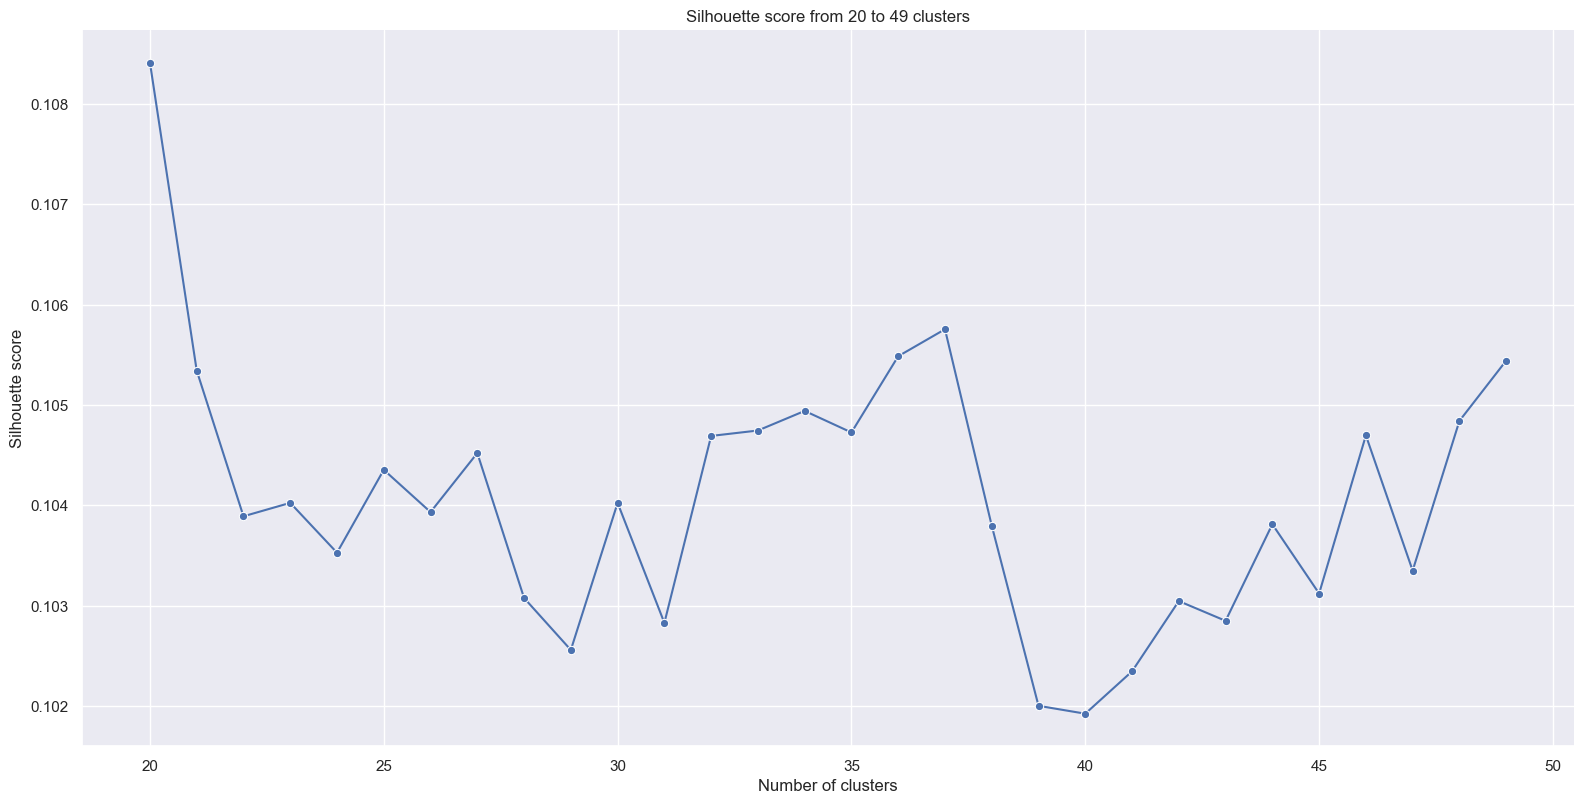

In [135]:
(
sns.relplot(y = sil_scores,
            x = range(20, max_k),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
.set(title=f"Silhouette score from 20 to {max_k - 1} clusters")
.set_axis_labels("Number of clusters", "Silhouette score")
);

In [189]:
my_kmeans = KMeans(n_clusters = 20, # you always choose the number of k here
                   random_state = 42)

# Fit the model to the data
my_kmeans.fit(scaled_data)

# Obtain the cluster output
clusters = my_kmeans.labels_

# Attach the cluster output to our original DataFrame
scaled_data["cluster"] = clusters

In [197]:
scaled_data.groupby(by="cluster").mean()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,,,
0,-0.621021,-1.022096,-0.678273,0.139234,-0.255639,-0.276766,0.848936,0.865829,-0.075855,-0.662065,0.664244,0.624460
1,-0.601255,0.521071,0.380454,0.290158,-1.000000,0.578614,-0.290573,0.692003,-0.121601,-0.435873,0.745936,0.609376
2,0.569182,-0.069749,0.432141,0.317516,-0.546980,0.938055,0.122148,0.031460,-0.322258,0.487844,0.724992,0.578886
3,0.210410,0.048304,-0.837644,0.306638,-0.269784,-0.152392,0.099284,0.111696,0.887766,0.356794,0.741782,0.569618
4,0.093045,-0.685329,-0.711651,0.234611,-0.075697,-0.333290,0.688332,0.111011,-0.035807,0.085009,0.714034,0.576393
5,0.368758,-0.171203,0.363498,0.285257,0.000000,-0.293550,0.239515,0.070771,-0.307202,0.607379,0.727248,0.570947
6,0.501971,-0.064500,-0.733550,0.312177,-0.305164,0.962393,0.149457,0.038813,-0.240208,0.387346,0.735813,0.575072
7,0.200408,0.154097,0.362108,0.326863,-1.000000,-0.067221,-0.032856,0.111479,0.988264,0.178435,0.748774,0.583710
8,0.221500,0.080761,0.317466,0.306704,0.000000,-0.271189,0.112179,0.122375,0.923427,0.447739,0.740471,0.572843


In [198]:

print(f"\nCluster distribution:")
cluster_counts = pd.Series(clusters).value_counts().sort_index()
for i, count in enumerate(cluster_counts):
    print(f"  Cluster {i}: {count} songs ({count/len(scaled_data)*100:.1f}%)")






Cluster distribution:
  Cluster 0: 266 songs (5.1%)
  Cluster 1: 231 songs (4.4%)
  Cluster 2: 298 songs (5.7%)
  Cluster 3: 278 songs (5.3%)
  Cluster 4: 251 songs (4.8%)
  Cluster 5: 352 songs (6.7%)
  Cluster 6: 213 songs (4.1%)
  Cluster 7: 217 songs (4.1%)
  Cluster 8: 248 songs (4.7%)
  Cluster 9: 302 songs (5.8%)
  Cluster 10: 228 songs (4.4%)
  Cluster 11: 246 songs (4.7%)
  Cluster 12: 260 songs (5.0%)
  Cluster 13: 225 songs (4.3%)
  Cluster 14: 257 songs (4.9%)
  Cluster 15: 323 songs (6.2%)
  Cluster 16: 220 songs (4.2%)
  Cluster 17: 215 songs (4.1%)
  Cluster 18: 352 songs (6.7%)
  Cluster 19: 253 songs (4.8%)


In [199]:
out_of_range_features = ['tempo', 'duration_ms', 'loudness', 'instrumentalness']
df_out = scaled_data[out_of_range_features]

scaler = MinMaxScaler()
scaled_out = scaler.fit_transform(df_out)

# scaled_data1 = scaled_data.copy()
scaled_data[out_of_range_features] = pd.DataFrame(scaled_out, columns=out_of_range_features)

scatter_objects = []

# State the label for each arm of the chart
categories = scaled_data.columns

# Get the means of each feature for each cluster
cluster_feat_means = scaled_data.groupby(by="cluster").mean()

# Iterate over the unique clusters and add an object for each cluster to the list
for cluster in sorted(scaled_data['cluster'].unique()):

  # Find the mean value for each column of the cluster
  cluster_means = cluster_feat_means.loc[cluster]

  # Create a Scatterpolar object for the cluster
  cluster_scatter = go.Scatterpolar(
    r = cluster_means, # set the radial coordinates
    theta = categories, # the names of the columns
    fill = 'toself', # fills in the space with colour
    name = f'Cluster {cluster}' # adds the name of the cluster
  )

  # Add the Scatterpolar object to the list
  scatter_objects.append(cluster_scatter)

# Create the figure (the white area)
fig = go.Figure()

# Add the scatter objects to the figure
fig.add_traces(scatter_objects)

# Add extras to the plot, such as title
fig.update_layout(
  title_text = 'Radar chart of mean play lists features for each cluster',
  height = 600,
  width = 800,
  polar = dict(
    radialaxis = dict(
      visible = True, # visibility of the numbers on the arm
      range = [0, 1] # scale of the plot
    )),
  showlegend = True
)

# Show the initialised plot and the trace objects
fig.show()

Feature ranges (largest to smallest):
duration_ms         12.685030
loudness             9.885679
tempo                7.877572
liveness             3.171529
speechiness          3.126866
danceability         2.535675
valence              2.028234
energy               1.932369
key                  1.891800
acousticness         1.210440
instrumentalness     1.091195
mode                 1.000000
dtype: float64


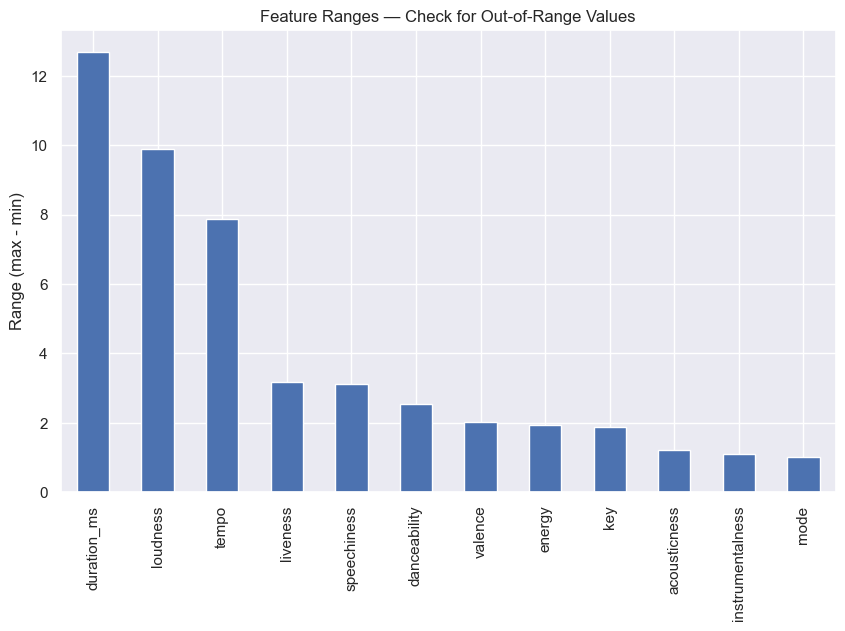

In [175]:
import pandas as pd
import matplotlib.pyplot as plt

# Suppose data_final is your features DataFrame
feature_ranges = (data_final.max() - data_final.min()).sort_values(ascending=False)

print("Feature ranges (largest to smallest):")
print(feature_ranges)

# Make a simple bar chart of the ranges
plt.figure(figsize=(10, 6))
feature_ranges.plot(kind='bar')
plt.ylabel("Range (max - min)")
plt.title("Feature Ranges — Check for Out-of-Range Values")
plt.show()

In [179]:
out_of_range_features = ['tempo', 'duration_ms', 'loudness']

df_out = data_final[out_of_range_features]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_out)

scaled_out_df = pd.DataFrame(scaled, columns=out_of_range_features)

print(scaled_out_df.describe().loc[['min','max']])

     tempo  duration_ms  loudness
min    0.0          0.0       0.0
max    1.0          1.0       1.0


In [143]:
pca = PCA()

# Fit the PCA object to the data
pca.fit(data_final)

# Transform scaled_features_df based on the fit calculations
pca_basic_df = pca.transform(data_final)

pca_basic_df

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11
name,,,,,,,,,,,,
Se Eu Quiser Falar Com Deus,-0.752553,-0.189505,0.312355,-0.120291,0.815158,1.607028,0.748507,-0.335385,-0.440142,-0.149723,0.211447,0.057197
Saudade De Bahia,-0.177127,-1.196795,0.669378,0.575250,-0.478195,-0.119217,0.013774,0.217468,0.214338,-0.242330,0.292610,-0.083094
"Canta Canta, Minha Gente",0.731266,-1.318843,0.232747,-0.745127,-0.439593,-0.362823,1.457671,0.543341,0.195375,-0.010954,-0.049249,0.355908
Mulher Eu Sei,-0.742271,-1.432242,0.286112,0.086124,-0.330469,1.182789,0.556996,0.337212,-0.147419,-0.159926,0.261935,0.024701
Rosa Morena,-1.432962,-0.688352,0.808689,0.636069,0.203425,0.086711,0.209712,0.418482,-0.208451,-0.264229,0.207996,0.178674
...,...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",-3.680585,1.692577,0.868433,0.002275,-0.377038,-0.334172,0.092366,0.285348,-0.152110,0.169652,-0.173106,-0.036593
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",-3.554046,1.502669,0.811104,-0.190509,0.115399,-0.390598,-0.130303,0.389421,-0.268787,0.054727,-0.179348,-0.023216
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",-3.093863,-0.939864,-0.852661,-0.635140,0.624776,-0.301068,-0.095422,0.475877,0.113058,-0.184369,-0.112960,0.011221


In [144]:
explained_variance_array = pca.explained_variance_ratio_

explained_variance_array

array([0.25012675, 0.18983341, 0.12452681, 0.10325719, 0.07882639,
       0.07716264, 0.05430668, 0.04422031, 0.03103036, 0.01989457,
       0.01864123, 0.00817365])

In [145]:
pd.DataFrame(explained_variance_array, columns=["Variance explained"])

,Variance explained
0,0.250127
1,0.189833
2,0.124527
3,0.103257
4,0.078826
5,0.077163
6,0.054307
7,0.044220
8,0.031030
9,0.019895


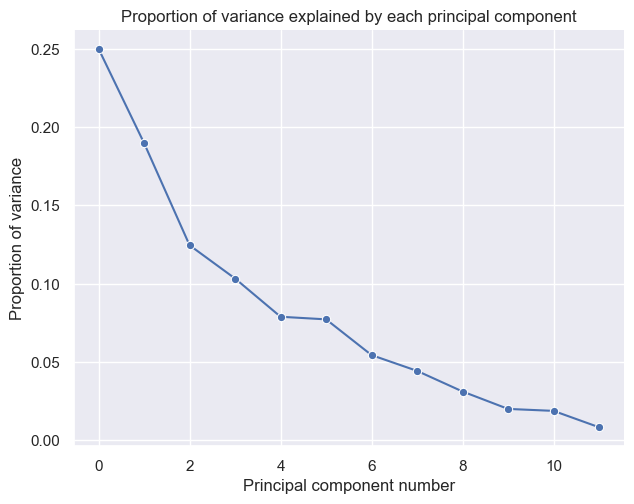

In [164]:
explained_variance_array_df = pd.DataFrame(explained_variance_array, columns=["Variance explained"])

(
  # Create a line chart with sns.relplot
  sns.relplot(
      kind = 'line',
      data = explained_variance_array_df,
      x = explained_variance_array_df.index,
      y = "Variance explained",
      marker = 'o',
      aspect = 1.3)
  # Set the title of the plot
  .set(title = "Proportion of variance explained by each principal component")
  # Set the axis labels
  .set_axis_labels("Principal component number", "Proportion of variance")
);

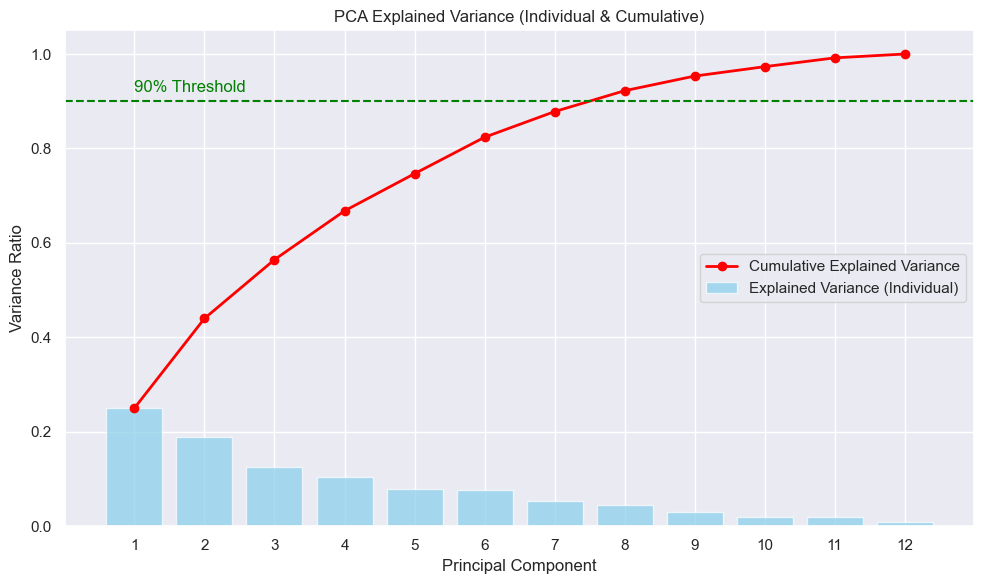

In [165]:
cumulative_variance = np.cumsum(explained_variance_array)

# Plot
plt.figure(figsize=(10, 6))

# Bars: individual explained variance
plt.bar(
    range(1, len(explained_variance_array) + 1),
    explained_variance_array,
    alpha=0.7,
    label="Explained Variance (Individual)",
    color="skyblue"
)

# Line: cumulative explained variance
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    color="red",
    linewidth=2,
    label="Cumulative Explained Variance"
)

# Optional threshold line (e.g., 90%)
threshold = 0.90
plt.axhline(y=threshold, color='green', linestyle='--', linewidth=1.5)
plt.text(1, threshold + 0.02, '90% Threshold', color='green')

# Labels and title
plt.xticks(range(1, len(explained_variance_array) + 1))
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title("PCA Explained Variance (Individual & Cumulative)")
plt.legend()

plt.tight_layout()
plt.show()


In [163]:
# Calculate the cumulative sum
cumulative_sum = np.cumsum(explained_variance_array)

# Find the index where the cumulative sum reaches 0.95
index = np.searchsorted(cumulative_sum, 0.90)

# Print the number of components required to reach 0.95 variance
print(index + 1)

8


In [162]:
elbow = 8

In [166]:
pca_elbow = PCA(n_components = elbow + 1)

# Fit the PCA object to the scaled features dataframe and transform it
pca_elbow_df = pca_elbow.fit_transform(data_final)

# The dataframe now contains the principal components of the scaled features dataframe
pca_elbow_df

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8
name,,,,,,,,,
Se Eu Quiser Falar Com Deus,-0.752553,-0.189505,0.312355,-0.120291,0.815158,1.607028,0.748507,-0.335385,-0.440142
Saudade De Bahia,-0.177127,-1.196795,0.669378,0.575250,-0.478195,-0.119217,0.013774,0.217468,0.214338
"Canta Canta, Minha Gente",0.731266,-1.318843,0.232747,-0.745127,-0.439593,-0.362823,1.457671,0.543341,0.195375
Mulher Eu Sei,-0.742271,-1.432242,0.286112,0.086124,-0.330469,1.182789,0.556996,0.337212,-0.147419
Rosa Morena,-1.432962,-0.688352,0.808689,0.636069,0.203425,0.086711,0.209712,0.418482,-0.208451
...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",-3.680585,1.692577,0.868433,0.002275,-0.377038,-0.334172,0.092366,0.285348,-0.152110
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",-3.554046,1.502669,0.811104,-0.190509,0.115399,-0.390598,-0.130303,0.389421,-0.268787
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",-3.093863,-0.939864,-0.852661,-0.635140,0.624776,-0.301068,-0.095422,0.475877,0.113058
